# Threshold 阈值概率转换 — 示例与典型验证

本 Notebook 演示修改后 `Threshold` 插件的典型用法，并与 Improver 原算法、官方 KGO 对照。

## 读图前须知

- **修改后**：`threshold.src.threshold.Threshold`，输入 **meb 六维** `DataArray`
- **原方法**：`improver.threshold.Threshold`，输入 **Iris Cube**
- **KGO**：官方 acceptance 期望结果（Known Good Output）

**vicinity** 特殊：原方法实现米制邻域只支持等面积投影，邻域逻辑以 **投影对照** 为准；经纬小节为有界对照。

各小节从 **读取输入文件** 开始，完整回归见 `threshold_probability_conversion/test/test_threshold.py`。


## 1. 环境准备

导入依赖、设置路径，并定义测试数据常量。

- 不在此节读取业务数据；各场景小节自行读取
- `Threshold`：修改后插件；`OrigThreshold`：Improver 原实现
- `*_PROJ`：投影样例；`*_LL`：经纬样例（`latlon/` 子目录）


In [1]:
%matplotlib inline

from __future__ import annotations

import sys
import warnings
from pathlib import Path

import iris
import matplotlib.pyplot as plt
import meteva_base as meb
import numpy as np
import xarray as xr
from iris.analysis import Nearest

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

# 中文字体（Windows 常见字体）
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 目录：notebook 在 threshold_probability_conversion/nbs/，数据在 threshold_probability_conversion/test_data/
PACKAGE_ROOT = Path.cwd().resolve().parent
PROJECT_ROOT = PACKAGE_ROOT.parent
IMPROVER_ROOT = PROJECT_ROOT / "improver-1.18.7"
DATA_DIR = PACKAGE_ROOT / "test_data"

for path in (str(PROJECT_ROOT), str(IMPROVER_ROOT)):
    if path not in sys.path:
        sys.path.insert(0, path)

from improver.threshold import Threshold as OrigThreshold  # pyright: ignore[reportMissingImports]
from threshold_probability_conversion.cli.prb_threshold import process as threshold_cli_process
from threshold_probability_conversion.src.threshold import Threshold

# ---- 投影路径（与官方 KGO 同网）----
BASIC_MEB_PROJ = DATA_DIR / "basic" / "cli_inputs" / "input_meb.nc"
BASIC_IRIS_PROJ = DATA_DIR / "basic" / "input.nc"
BASIC_KGO_PROJ = DATA_DIR / "basic" / "kgo.nc"
MULTI_KGO_PROJ = DATA_DIR / "multiple_thresholds" / "kgo.nc"
FUZZY_KGO_PROJ = DATA_DIR / "fuzzy_factor" / "kgo.nc"
VIC_MEB_PROJ = DATA_DIR / "vicinity" / "cli_inputs" / "input_meb.nc"
VIC_IRIS_PROJ = DATA_DIR / "vicinity" / "input.nc"
VIC_KGO_PROJ = DATA_DIR / "vicinity" / "kgo.nc"

# ---- 经纬路径（业务主输入；KGO 由投影结果重网格）----
BASIC_MEB_LL = DATA_DIR / "basic" / "latlon" / "cli_inputs" / "input_meb.nc"
BASIC_IRIS_LL = DATA_DIR / "basic" / "latlon" / "input.nc"
BASIC_KGO_LL = DATA_DIR / "basic" / "latlon" / "kgo.nc"
MULTI_KGO_LL = DATA_DIR / "multiple_thresholds" / "latlon" / "kgo.nc"
FUZZY_KGO_LL = DATA_DIR / "fuzzy_factor" / "latlon" / "kgo.nc"
VIC_MEB_LL = DATA_DIR / "vicinity" / "latlon" / "cli_inputs" / "input_meb.nc"
VIC_KGO_LL = DATA_DIR / "vicinity" / "latlon" / "kgo.nc"

# KGO 中常见无效填充值，统计时排除
FILL_THRESHOLD = 1.0e30
print("DATA_DIR =", DATA_DIR)


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_DIR = D:\workspace\improver\threshold\test_data


## 2. 对照辅助函数

将 Iris Cube / meb `DataArray` 统一为 `(member, level, lat, lon)` 四维数组，便于：

- `compare_stats`：打印 MAE / max / RMSE（排除巨大 fill）
- `plot_triple`：三列图（修改后 / KGO / 原方法）

**硬阈值**用离散色标（0/1）；**fuzzy** 用连续色标（0–1）。


In [2]:
from matplotlib.colors import BoundaryNorm, ListedColormap


def _threshold_dim_coord(cube):
    """在 Iris Cube 中定位阈值维（官方可能叫 threshold 或 rainfall_rate 等）。"""
    for c in cube.coords(dim_coords=True):
        if c.var_name == "threshold":
            return c
        if "spp__relative_to_threshold" in c.attributes:
            return c
        if "threshold" in c.name():
            return c
    return None


def iris_to_member_level_yx(cube) -> np.ndarray:
    """Iris Cube → (member, level, y, x)；单阈值时 level 维长度为 1。"""
    thr = _threshold_dim_coord(cube)
    arr = np.ma.filled(cube.data, np.nan) if np.ma.isMaskedArray(cube.data) else np.asarray(cube.data)
    arr = np.asarray(arr, dtype=np.float64)
    if thr is not None:
        axis = cube.coord_dims(thr)[0]
        if axis != 1:
            arr = np.moveaxis(arr, axis, 1)  # 阈值维统一到 axis=1
        while arr.ndim > 4:
            arr = arr[0]  # 去掉 time 等长度为 1 的维
        return arr
    while arr.ndim > 3:
        arr = arr[0]
    return arr[:, np.newaxis, ...] if arr.ndim == 3 else arr[np.newaxis, np.newaxis, ...]


def meb_to_member_level_yx(result: xr.DataArray) -> np.ndarray:
    """meb 六维输出 → (member, level, y, x)，压掉 time/dtime 等单点维。"""
    arr = np.asarray(result.values, dtype=np.float64)
    for ax in (3, 2):  # dtime, time
        if arr.ndim > 4 and arr.shape[ax] == 1:
            arr = np.squeeze(arr, axis=ax)
    while arr.ndim > 4:
        arr = arr[0]
    return arr


def meb_vicinity_to_level_yx(result: xr.DataArray) -> np.ndarray:
    """vicinity 结果：压掉 time/dtime，保留 (member, level, lat, lon)。"""
    return np.squeeze(np.asarray(result.values, dtype=np.float64), axis=(2, 3))


def field_2d(arr, *, member_index: int = 0, level_index: int = 0) -> np.ndarray:
    """取单 member、单 level 的二维场用于作图。"""
    if hasattr(arr, "data") and hasattr(arr, "coord"):
        arr = iris_to_member_level_yx(arr)
    elif isinstance(arr, xr.DataArray):
        arr = meb_to_member_level_yx(arr)
    a = np.asarray(arr, dtype=np.float64)
    if a.ndim == 4:
        return a[member_index, level_index]
    if a.ndim == 3:
        return a[level_index]
    if a.ndim == 2:
        return a
    raise ValueError(f"无法切片为 2D，shape={a.shape}")


def valid_mask(*arrays, fill=FILL_THRESHOLD):
    """有效格点：有限且非 KGO 巨大填充值。"""
    mask = np.ones(arrays[0].shape, dtype=bool)
    for a in arrays:
        aa = np.asarray(a, dtype=np.float64)
        mask &= np.isfinite(aa) & (np.abs(aa) < fill)
    return mask


def compare_stats(a, b, title: str) -> None:
    """打印两组场的 MAE / max / RMSE。"""
    aa, bb = np.asarray(a, dtype=np.float64), np.asarray(b, dtype=np.float64)
    m = valid_mask(aa, bb)
    diff = np.abs(aa[m] - bb[m])
    print(
        f"[{title}] MAE={diff.mean():.8f}, "
        f"max={diff.max():.8f}, RMSE={np.sqrt((diff ** 2).mean()):.8f}"
    )


def plot_triple(
    modified,
    kgo,
    original,
    title: str,
    *,
    member_index: int = 0,
    level_index: int = 0,
    discrete: bool = False,
):
    """三列对比图：修改后 / KGO / 原方法。"""
    panels = [
        (field_2d(modified, member_index=member_index, level_index=level_index), "修改后"),
        (field_2d(kgo, member_index=member_index, level_index=level_index), "KGO"),
        (field_2d(original, member_index=member_index, level_index=level_index), "原方法"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    if discrete:
        # 硬阈值 0/1：两色，色标只标 0 和 1
        cmap = ListedColormap(["#2166ac", "#b2182b"])
        norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)
        im_kw = dict(cmap=cmap, norm=norm, origin="lower")
        cbar_ticks = [0, 1]
    else:
        im_kw = dict(cmap="viridis", origin="lower", vmin=0.0, vmax=1.0)
        cbar_ticks = None
    for ax, (field, label) in zip(axes, panels):
        im = ax.imshow(field, **im_kw)
        ax.set_title(label)
        ax.set_xticks([])
        ax.set_yticks([])
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if cbar_ticks is not None:
            cbar.set_ticks(cbar_ticks)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


## 3. 硬阈值

对气温场做「大于 280 K」的 0/1 概率场（`threshold_values=280`，默认比较符 `>`）。

- 输出 `level` 维长度为 1（单阈值）
- 投影小节：应与官方 KGO **几乎完全一致**（MAE ≈ 0）
- 经纬小节：迁后与原方法仍应一致；与重网格 KGO 可能有插值误差


### 3.1 投影输入

| 角色 | 文件 |
|------|------|
| 迁后输入 | `basic/cli_inputs/input_meb.nc` |
| 原方法输入 | `basic/input.nc` |
| KGO | `basic/kgo.nc` |


[硬阈值·投影 修改后 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[硬阈值·投影 原方法 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[硬阈值·投影 修改后 vs 原方法] MAE=0.00000000, max=0.00000000, RMSE=0.00000000


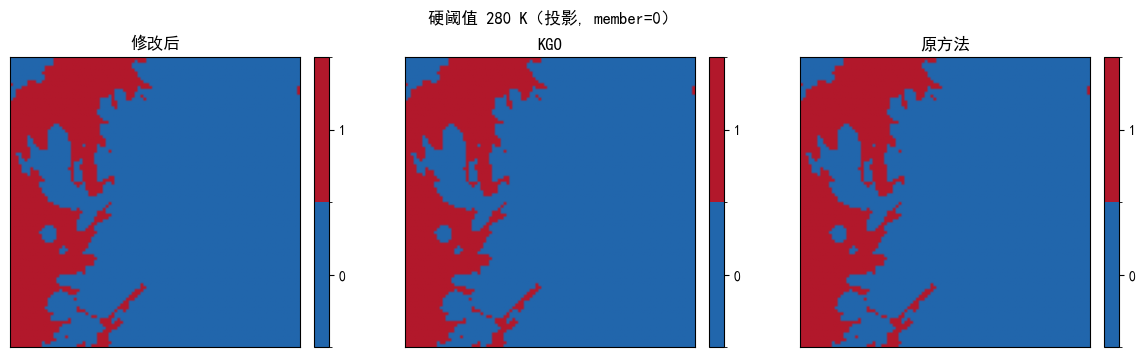

In [3]:
# 1) 读入输入与 KGO
basic_meb = meb.read_griddata_from_nc(str(BASIC_MEB_PROJ))
basic_cube = iris.load_cube(str(BASIC_IRIS_PROJ))
kgo_cube = iris.load_cube(str(BASIC_KGO_PROJ))

# 2) 调用插件：修改后插件方法
modified = Threshold(threshold_values=280.0).process(basic_meb)
# 原方法插件调用
original = OrigThreshold(threshold_values=280.0).process(basic_cube.copy())

# 3) 与 KGO、原方法对照（离散 0/1 色标）
mod_arr = meb_to_member_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_cube)
orig_arr = iris_to_member_level_yx(original)

compare_stats(mod_arr, kgo_arr, "硬阈值·投影 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "硬阈值·投影 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "硬阈值·投影 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "硬阈值 280 K（投影, member=0）",
    discrete=True,
)


### 3.2 经纬输入

| 角色 | 文件 |
|------|------|
| 迁后输入 | `basic/latlon/cli_inputs/input_meb.nc` |
| 原方法输入 | `basic/latlon/input.nc`（Improver 支持经纬 Cube） |
| KGO | `basic/latlon/kgo.nc` |


[硬阈值·经纬 修改后 vs KGO] MAE=0.01303077, max=1.00000000, RMSE=0.11415238
[硬阈值·经纬 原方法 vs KGO] MAE=0.01303077, max=1.00000000, RMSE=0.11415238
[硬阈值·经纬 修改后 vs 原方法] MAE=0.00000000, max=0.00000000, RMSE=0.00000000


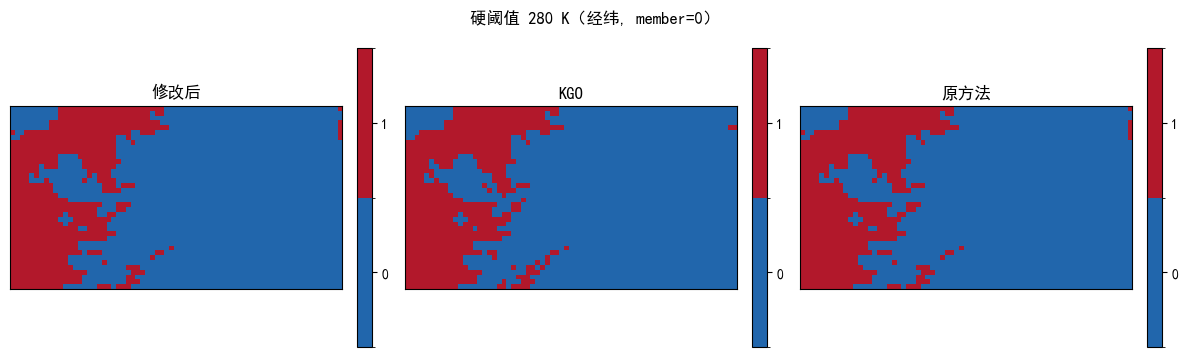

In [4]:
# 1) 读入输入与 KGO
basic_meb = meb.read_griddata_from_nc(str(BASIC_MEB_LL))
basic_cube = iris.load_cube(str(BASIC_IRIS_LL))
kgo_cube = iris.load_cube(str(BASIC_KGO_LL))

# 2) 调用插件：修改后插件方法
modified = Threshold(threshold_values=280.0).process(basic_meb)
# 原方法插件调用
original = OrigThreshold(threshold_values=280.0).process(basic_cube.copy())

# 3) 与 KGO、原方法对照（离散 0/1 色标）
mod_arr = meb_to_member_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_cube)
orig_arr = iris_to_member_level_yx(original)

compare_stats(mod_arr, kgo_arr, "硬阈值·经纬 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "硬阈值·经纬 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "硬阈值·经纬 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "硬阈值 280 K（经纬, member=0）",
    discrete=True,
)


## 4. 多阈值

一次传入多个阈值 `[270, 280, 290]`，输出沿 `level` 维堆叠（3 个概率层）。

- 作图默认取 `level_index=1`（280 K）
- 可先打印各 level 上 0/1 格点计数，确认阈值是否合理


### 4.1 投影输入

| 角色 | 文件 |
|------|------|
| 迁后输入 | `basic/cli_inputs/input_meb.nc` |
| 原方法输入 | `basic/input.nc` |
| KGO | `multiple_thresholds/kgo.nc` |


level 坐标: [np.float32(270.0), np.float32(280.0), np.float32(290.0)]
  level[0]=270.0 K: ones=10000, zeros=0
  level[1]=280.0 K: ones=2370, zeros=7630
  level[2]=290.0 K: ones=0, zeros=10000
[多阈值·投影 修改后 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[多阈值·投影 原方法 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[多阈值·投影 修改后 vs 原方法] MAE=0.00000000, max=0.00000000, RMSE=0.00000000


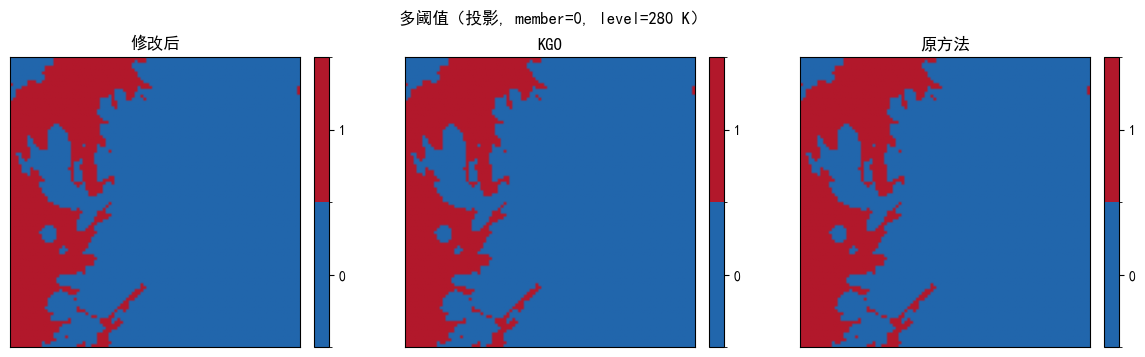

In [5]:
# 阈值
thresholds = [270.0, 280.0, 290.0]

# 1) 读入输入与 KGO
basic_meb = meb.read_griddata_from_nc(str(BASIC_MEB_PROJ))
basic_cube = iris.load_cube(str(BASIC_IRIS_PROJ))
kgo_cube = iris.load_cube(str(MULTI_KGO_PROJ))

# 2) 调用插件：修改后插件方法
modified = Threshold(threshold_values=thresholds).process(basic_meb)
# 原方法插件调用
original = OrigThreshold(threshold_values=thresholds).process(basic_cube.copy())

# 3) 与 KGO、原方法对照（离散 0/1 色标）
mod_arr = meb_to_member_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_cube)
orig_arr = iris_to_member_level_yx(original)

# 各阈值层 0/1 统计（本样例气温约 272–282 K，270 层可能全为 1）
print("level 坐标:", list(np.asarray(modified.coords["level"].values)))
for i, thr in enumerate(thresholds):
    plane = field_2d(mod_arr, member_index=0, level_index=i)
    print(f"  level[{i}]={thr} K: ones={int(np.nansum(plane == 1))}, zeros={int(np.nansum(plane == 0))}")

compare_stats(mod_arr, kgo_arr, "多阈值·投影 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "多阈值·投影 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "多阈值·投影 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "多阈值（投影, member=0, level=280 K）",
    discrete=True,
    level_index=1,
)


### 4.2 经纬输入

| 角色 | 文件 |
|------|------|
| 迁后输入 | `basic/latlon/cli_inputs/input_meb.nc` |
| 原方法输入 | `basic/latlon/input.nc` |
| KGO | `multiple_thresholds/latlon/kgo.nc` |


[多阈值·经纬 修改后 vs KGO] MAE=0.00434359, max=1.00000000, RMSE=0.06590591
[多阈值·经纬 原方法 vs KGO] MAE=0.00434359, max=1.00000000, RMSE=0.06590591
[多阈值·经纬 修改后 vs 原方法] MAE=0.00000000, max=0.00000000, RMSE=0.00000000


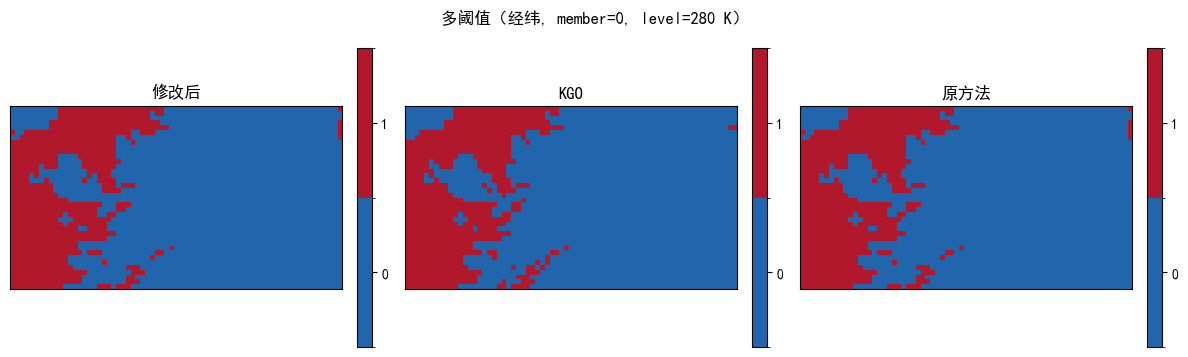

In [6]:
# 阈值
thresholds = [270.0, 280.0, 290.0]

# 1) 读入输入与 KGO
basic_meb = meb.read_griddata_from_nc(str(BASIC_MEB_LL))
basic_cube = iris.load_cube(str(BASIC_IRIS_LL))
kgo_cube = iris.load_cube(str(MULTI_KGO_LL))

# 2) 调用插件：修改后插件方法
modified = Threshold(threshold_values=thresholds).process(basic_meb)
# 原方法插件调用
original = OrigThreshold(threshold_values=thresholds).process(basic_cube.copy())

# 3) 与 KGO、原方法对照（离散 0/1 色标）
mod_arr = meb_to_member_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_cube)
orig_arr = iris_to_member_level_yx(original)

compare_stats(mod_arr, kgo_arr, "多阈值·经纬 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "多阈值·经纬 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "多阈值·经纬 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "多阈值（经纬, member=0, level=280 K）",
    discrete=True, level_index=1,
)


## 5. Fuzzy 阈值

`fuzzy_factor=0.99` 在阈值附近做线性过渡，输出 **0–1 连续** 场（非严格 0/1）。

- 作图使用连续色标 `viridis`
- 投影路径应与 KGO 高度一致


### 5.1 投影输入

| 角色 | 文件 |
|------|------|
| 迁后输入 | `basic/cli_inputs/input_meb.nc` |
| 原方法输入 | `basic/input.nc` |
| KGO | `fuzzy_factor/kgo.nc` |


[fuzzy·投影 修改后 vs KGO] MAE=0.00000054, max=0.00000218, RMSE=0.00000085
[fuzzy·投影 原方法 vs KGO] MAE=0.00000050, max=0.00000221, RMSE=0.00000079
[fuzzy·投影 修改后 vs 原方法] MAE=0.00000063, max=0.00000221, RMSE=0.00000117


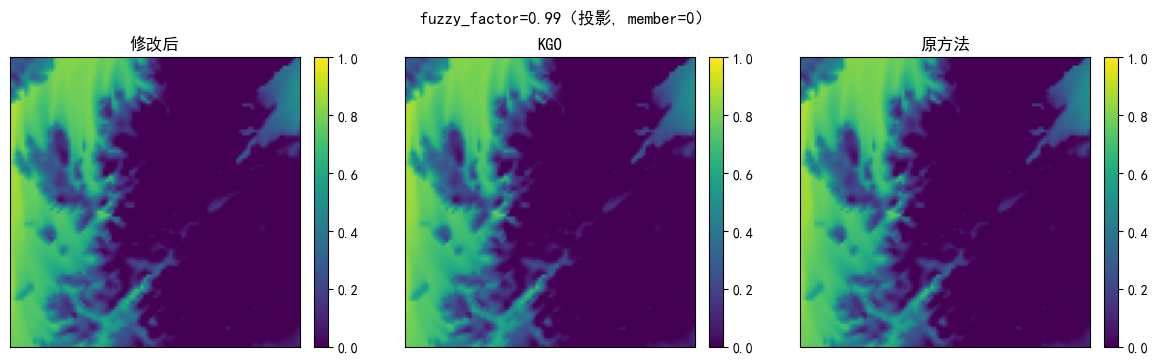

In [7]:
# 1) 读入输入与 KGO
basic_meb = meb.read_griddata_from_nc(str(BASIC_MEB_PROJ))
basic_cube = iris.load_cube(str(BASIC_IRIS_PROJ))
kgo_cube = iris.load_cube(str(FUZZY_KGO_PROJ))

# 2) 调用插件：修改后插件方法
modified = Threshold(threshold_values=280.0, fuzzy_factor=0.99).process(basic_meb)
# 原方法插件调用
original = OrigThreshold(threshold_values=280.0, fuzzy_factor=0.99).process(
    basic_cube.copy()
)

# 3) 与 KGO、原方法对照
mod_arr = meb_to_member_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_cube)
orig_arr = iris_to_member_level_yx(original)

compare_stats(mod_arr, kgo_arr, "fuzzy·投影 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "fuzzy·投影 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "fuzzy·投影 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "fuzzy_factor=0.99（投影, member=0）",
    discrete=False,
)


### 5.2 经纬输入

| 角色 | 文件 |
|------|------|
| 迁后输入 | `basic/latlon/cli_inputs/input_meb.nc` |
| 原方法输入 | `basic/latlon/input.nc` |
| KGO | `fuzzy_factor/latlon/kgo.nc` |


[fuzzy·经纬 修改后 vs KGO] MAE=0.01342641, max=0.31397244, RMSE=0.03073491
[fuzzy·经纬 原方法 vs KGO] MAE=0.01342640, max=0.31397244, RMSE=0.03073490
[fuzzy·经纬 修改后 vs 原方法] MAE=0.00000063, max=0.00000221, RMSE=0.00000117


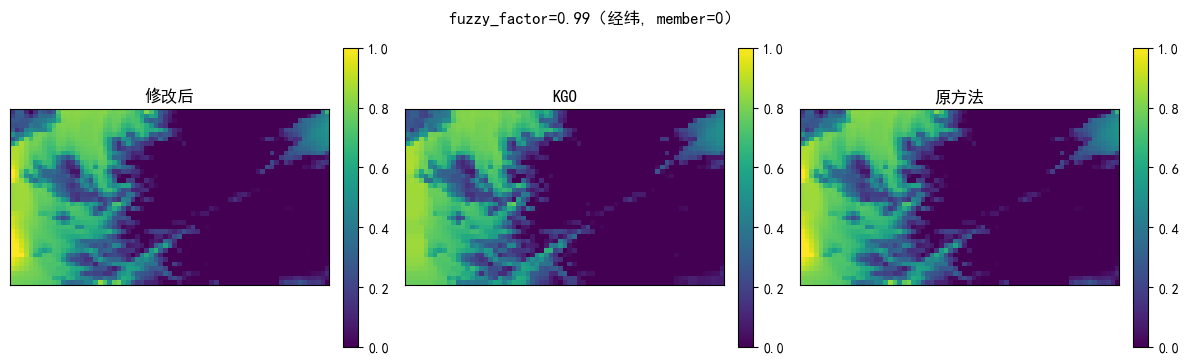

In [8]:
# 1) 读入输入与 KGO
basic_meb = meb.read_griddata_from_nc(str(BASIC_MEB_LL))
basic_cube = iris.load_cube(str(BASIC_IRIS_LL))
kgo_cube = iris.load_cube(str(FUZZY_KGO_LL))

# 2) 调用插件：修改后插件方法
modified = Threshold(threshold_values=280.0, fuzzy_factor=0.99).process(basic_meb)
# 原方法插件调用
original = OrigThreshold(threshold_values=280.0, fuzzy_factor=0.99).process(
    basic_cube.copy()
)

# 3) 与 KGO、原方法对照（离散 0/1 色标）
mod_arr = meb_to_member_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_cube)
orig_arr = iris_to_member_level_yx(original)

compare_stats(mod_arr, kgo_arr, "fuzzy·经纬 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "fuzzy·经纬 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "fuzzy·经纬 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "fuzzy_factor=0.99（经纬, member=0）",
    discrete=False,
)


## 6. Vicinity（邻域内最大值）

原方法邻域处理**不支持经纬输入**，本节分两条路径对照：

| 小节 | 迁后输入 | 原方法 / KGO | 预期差异 |
|------|----------|--------------|----------|
| **6.1 投影** | 投影 meb | 投影 Iris / 投影 KGO | **较小**（同网，MAE ≈ 0） |
| **6.2 经纬** | 经纬 meb | 投影结果重网格 | **较大**（先邻域再重网格 ≠ 先重网格再邻域） |

参数：`threshold_values=[0.03, 0.1, 1.0]`，`threshold_units="mm hr-1"`，`vicinity=10000`（10 km）。


### 6.1 投影输入

修改后插件方法、原方法、KGO 均在投影网计算，用于核对邻域逻辑。


[vicinity·投影 修改后 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[vicinity·投影 原方法 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[vicinity·投影 修改后 vs 原方法] MAE=0.00000000, max=0.00000000, RMSE=0.00000000


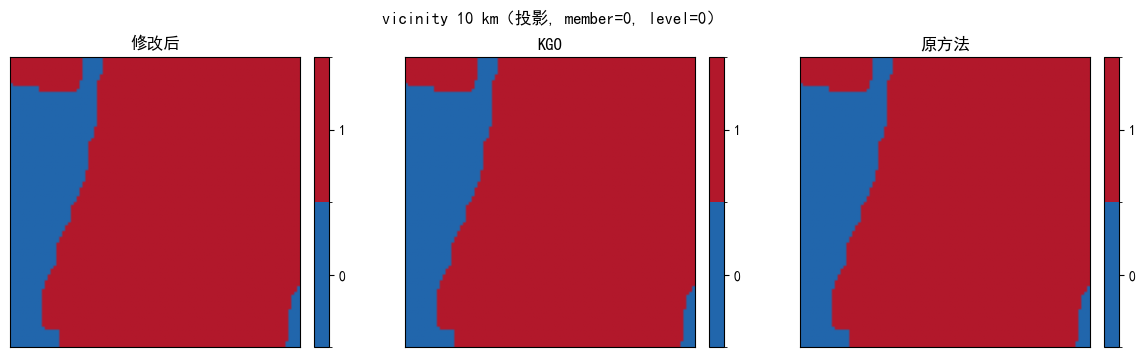

In [9]:
# 与KGO计算一致的参数
vic_kwargs = dict(
    threshold_values=[0.03, 0.1, 1.0],
    threshold_units="mm hr-1",
    vicinity=10000.0,
)

# 1) 读入输入与 KGO
vic_meb = meb.read_griddata_from_nc(str(VIC_MEB_PROJ))
vic_cube = iris.load_cube(str(VIC_IRIS_PROJ))
kgo_cube = iris.load_cube(str(VIC_KGO_PROJ))

# 2) 调用插件：修改后插件方法
modified = Threshold(**vic_kwargs).process(vic_meb)
# 原方法插件调用
original = OrigThreshold(**vic_kwargs).process(vic_cube.copy())

# 3) 与 KGO、原方法对照（离散 0/1 色标）
mod_arr = meb_vicinity_to_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_cube)
orig_arr = iris_to_member_level_yx(original)

compare_stats(mod_arr, kgo_arr, "vicinity·投影 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "vicinity·投影 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "vicinity·投影 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "vicinity 10 km（投影, member=0, level=0）",
    discrete=True,
)


### 6.2 经纬输入

修改后方法在经纬 meb 上直接计算；原方法与 KGO 均为投影结果重网格到同一经纬网。


[vicinity·经纬 修改后 vs KGO] MAE=0.03690603, max=1.00000000, RMSE=0.19210943
[vicinity·经纬 原方法 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[vicinity·经纬 修改后 vs 原方法] MAE=0.03690603, max=1.00000000, RMSE=0.19210943


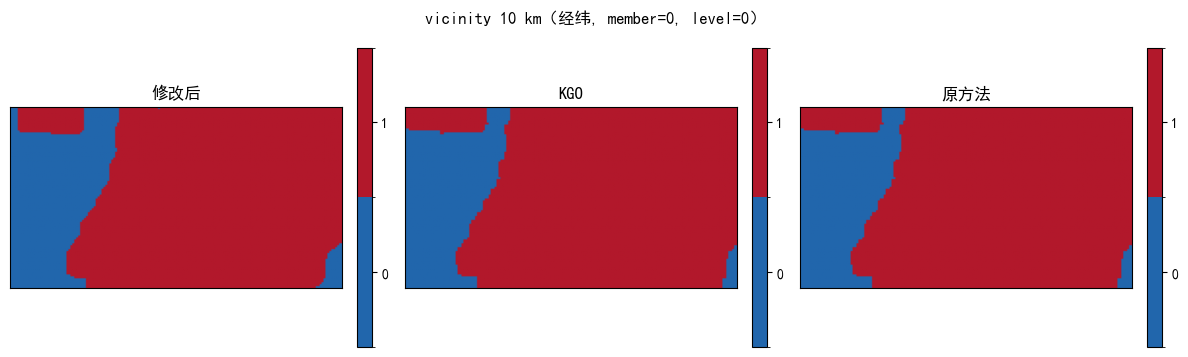

In [10]:
# 插件方法初始化参数
vic_kwargs = dict(
    threshold_values=[0.03, 0.1, 1.0],
    threshold_units="mm hr-1",
    vicinity=10000.0,
)

# 1) 读入输入与 KGO
vic_meb = meb.read_griddata_from_nc(str(VIC_MEB_LL))
vic_cube_proj = iris.load_cube(str(VIC_IRIS_PROJ))  # 原方法仍用投影输入
kgo_ll = iris.load_cube(str(VIC_KGO_LL))  # KGO 在预处理脚本中已进行了经纬转换，当前为经纬网格

# 修改后插件方法：直接在经纬网上做邻域处理
modified = Threshold(**vic_kwargs).process(vic_meb)

# 原方法：投影网计算 → Nearest 重网格到与 KGO 相同的经纬网
original_proj = OrigThreshold(**vic_kwargs).process(vic_cube_proj.copy())
original = original_proj.regrid(kgo_ll, Nearest(extrapolation_mode="extrapolate"))

# 3) 与 KGO、原方法对照（离散 0/1 色标）
mod_arr = meb_vicinity_to_level_yx(modified)
kgo_arr = iris_to_member_level_yx(kgo_ll)
orig_arr = iris_to_member_level_yx(original)

compare_stats(mod_arr, kgo_arr, "vicinity·经纬 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "vicinity·经纬 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "vicinity·经纬 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "vicinity 10 km（经纬, member=0, level=0）",
    discrete=True,
)


## 7. CLI 验证（投影）

`prb_threshold.process` 负责读 meb、调 `Threshold`、可选写出 NetCDF；**核心计算与上文插件相同**，故只做投影对照。

| 角色 | 文件 |
|------|------|
| 迁后 CLI 写出 | `basic/cli_outputs/cli_threshold_result.nc`（本节运行生成） |
| 原方法 CLI | `basic/cli_outputs/orig_cli_threshold_result.nc`（预生成，需事先用 `improver threshold` 生成） |
| KGO | `basic/kgo.nc` |


[CLI·投影 修改后 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[CLI·投影 原方法 vs KGO] MAE=0.00000000, max=0.00000000, RMSE=0.00000000
[CLI·投影 修改后 vs 原方法] MAE=0.00000000, max=0.00000000, RMSE=0.00000000


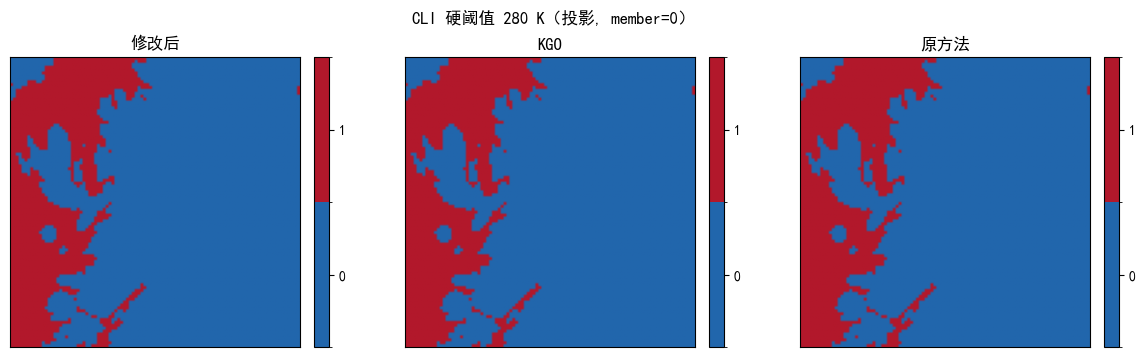

In [11]:
CLI_OUT_DIR = DATA_DIR / "basic" / "cli_outputs"
MIG_CLI_OUT = CLI_OUT_DIR / "cli_threshold_result.nc"
ORIG_CLI_OUT = CLI_OUT_DIR / "orig_cli_threshold_result.nc"
CLI_OUT_DIR.mkdir(parents=True, exist_ok=True)

if MIG_CLI_OUT.exists():
    MIG_CLI_OUT.unlink()

if not ORIG_CLI_OUT.exists():
    raise FileNotFoundError(
        f"缺少原方法 CLI 结果，请先用投影 Iris 输入运行 improver threshold 写出至:\n  {ORIG_CLI_OUT}"
    )

# 修改后插件方法 CLI：读投影 meb → 调 Threshold → 写出
threshold_cli_process(
    str(BASIC_MEB_PROJ),
    threshold_values=280.0,
    output_path=str(MIG_CLI_OUT),
)

# 读回写出文件，与 KGO、原 CLI 结果对照
mod_arr = meb_to_member_level_yx(meb.read_griddata_from_nc(str(MIG_CLI_OUT)))
kgo_arr = iris_to_member_level_yx(iris.load_cube(str(BASIC_KGO_PROJ)))
orig_arr = iris_to_member_level_yx(iris.load_cube(str(ORIG_CLI_OUT)))

compare_stats(mod_arr, kgo_arr, "CLI·投影 修改后 vs KGO")
compare_stats(orig_arr, kgo_arr, "CLI·投影 原方法 vs KGO")
compare_stats(mod_arr, orig_arr, "CLI·投影 修改后 vs 原方法")
plot_triple(
    mod_arr, kgo_arr, orig_arr,
    "CLI 硬阈值 280 K（投影, member=0）",
    discrete=True,
)


## 8. 小结

| 小节 | 投影对照 | 经纬对照 |
|------|----------|----------|
| 硬阈值 / 多阈值 / fuzzy | 同网 MAE ≈ 0 | 迁后≈原方法；与重网格 KGO 可有插值差 |
| vicinity | **逻辑核对关键**（同网 MAE ≈ 0） | 有界对照；边界差≠实现错误 |
| CLI | 仅投影（= 插件 + I/O） | — |

- 各小节均从 **读入输入** 开始，便于复制到业务脚本
- 更全场景（单位、JSON 配置、landmask、掩码降水等）见 `pytest threshold_probability_conversion/test`
